# Simulador de un sistema de comunicaciones digitales

Este notebook desarrolla por ahora los tres primeros bloques trabajados: el generador de hipotesis binarias equiprobables, el encoder con salida antipodal y el modelado del canal AWGN aplicado sobre la salida del encoder.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

plt.style.use("seaborn-v0_8-whitegrid")

# Parametros globales
seed = 20260515
rng = np.random.default_rng(seed)
num_bits = 20_000
preview_bits = 8
noise_variance = 0.5
ideal_channel = False

print(f"Semilla: {seed}")
print(f"Cantidad de bits simulados: {num_bits}")
print(f"Varianza del ruido: {noise_variance}")
print(f"Canal idealizado: {ideal_channel}")


Semilla: 20260515
Cantidad de bits simulados: 20000
Varianza del ruido: 0.5
Canal idealizado: False


## 1. Generador de hipotesis binarias equiprobables, H = {0, 1}

### Teoria

La fuente de informacion se modela como una variable aleatoria binaria `H` perteneciente al conjunto `{0,1}` y con probabilidades a priori iguales:

- `P(H=0)=1/2`
- `P(H=1)=1/2`

Esto significa que las dos hipotesis son equiprobables. Una forma conveniente de implementarlo es generar primero una variable aleatoria uniforme `U ~ Uniforme(0,1)` y luego decidir:

- `H = 0` si `U < 0.5`
- `H = 1` si `U >= 0.5`

De esta manera, ambas hipotesis tienen la misma probabilidad de ocurrencia. Esta idea conecta bien con la sugerencia de usar la distribucion `uniform`.

### Codigo


Primeros 20 bits generados: [1 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0]
Fraccion de ceros: 0.4995
Fraccion de unos : 0.5006


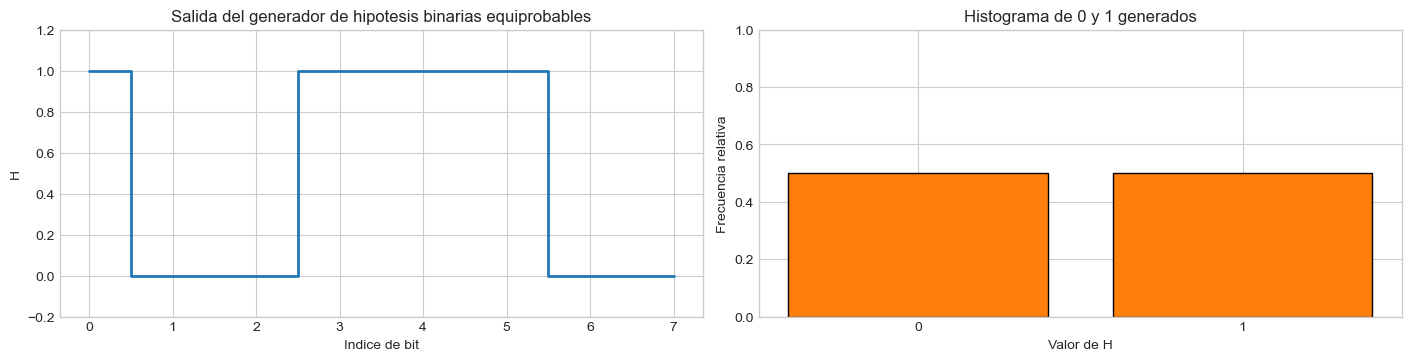

In [2]:
def generate_hypotheses(num_bits, rng):
    u = uniform.rvs(loc=0, scale=1, size=num_bits, random_state=rng)
    return (u >= 0.5).astype(int)


bits = generate_hypotheses(num_bits, rng)

print("Primeros 20 bits generados:", bits[:20])
print(f"Fraccion de ceros: {np.mean(bits == 0):.4f}")
print(f"Fraccion de unos : {np.mean(bits == 1):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), constrained_layout=True)

axes[0].step(np.arange(preview_bits), bits[:preview_bits], where="mid", linewidth=2)
axes[0].set_title("Salida del generador de hipotesis binarias equiprobables")
axes[0].set_xlabel("Indice de bit")
axes[0].set_ylabel("H")
axes[0].set_ylim(-0.2, 1.2)

axes[1].hist(bits, bins=[-0.5, 0.5, 1.5], density=True, rwidth=0.8, color="C1", edgecolor="black")
axes[1].set_title("Histograma de 0 y 1 generados")
axes[1].set_xlabel("Valor de H")
axes[1].set_ylabel("Frecuencia relativa")
axes[1].set_xticks([0, 1])
axes[1].set_ylim(0, 1)

plt.show()


## 2. Encoder con salida de palabra codigo binaria, C = {-1, +1}

### Teoria

El encoder transforma cada hipotesis binaria en un simbolo antipodal. Se usa el mapeo:

- `H = 0 -> c = -1`
- `H = 1 -> c = +1`

Por lo tanto, la salida del encoder pertenece al conjunto `C = {-1,+1}`. Este bloque es importante porque el canal ya no recibe directamente los bits `0` y `1`, sino los simbolos codificados `-1` y `+1`.

### Codigo


Primeros 20 bits: [1 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0]
Primeros 20 simbolos codificados: [ 1 -1 -1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1  1 -1  1 -1]


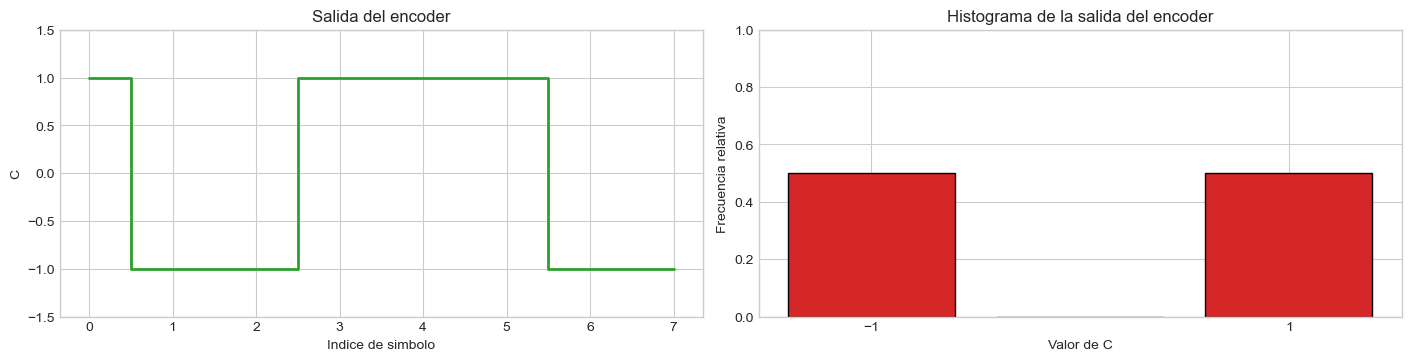

In [3]:
def encode_bpsk(bits):
    return np.where(bits == 0, -1.0, 1.0)


coded_symbols = encode_bpsk(bits)

print("Primeros 20 bits:", bits[:20])
print("Primeros 20 simbolos codificados:", coded_symbols[:20].astype(int))

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5), constrained_layout=True)

axes[0].step(np.arange(preview_bits), coded_symbols[:preview_bits], where="mid", linewidth=2, color="C2")
axes[0].set_title("Salida del encoder")
axes[0].set_xlabel("Indice de simbolo")
axes[0].set_ylabel("C")
axes[0].set_ylim(-1.5, 1.5)

axes[1].hist(coded_symbols, bins=[-1.5, -0.5, 0.5, 1.5], density=True, rwidth=0.8, color="C3", edgecolor="black")
axes[1].set_title("Histograma de la salida del encoder")
axes[1].set_xlabel("Valor de C")
axes[1].set_ylabel("Frecuencia relativa")
axes[1].set_xticks([-1, 1])
axes[1].set_ylim(0, 1)

plt.show()


## 3. Canal modelado como N(t) gaussiano aditivo blanco

### Teoria

El canal se modela como un canal AWGN (`Additive White Gaussian Noise`). Esto significa:

- Aditivo: el ruido se suma a la senal transmitida.
- Gaussiano: el ruido tiene distribucion normal.
- Blanco: sus muestras se consideran independientes dentro del modelo discreto ideal.

En tiempo continuo, si bajo la hipotesis `H=i` se transmite la senal `w_i(t)`, la salida del canal es:

- `R(t) = w_i(t) + N(t)`

donde `N(t)` es un ruido gaussiano blanco de media cero.

En el modelo discreto equivalente, la entrada del canal pasa a ser la salida del encoder, es decir `C[k] in {-1,+1}`. Entonces se usa:

- `n[k] ~ N(0, sigma_w^2)`
- `y[k] = C[k] + n[k]`

donde `sigma_w^2` es la varianza parametrizable del ruido.

Si queremos idealizar el canal, imponemos:

- `n[k] = 0` para todo `k`

y entonces la salida queda:

- `y[k] = C[k]`

### Codigo


In [4]:
def awgn_channel(tx_signal, noise_variance, rng, ideal=False):
    if ideal:
        noise = np.zeros_like(tx_signal)
    else:
        noise = rng.normal(loc=0.0, scale=np.sqrt(noise_variance), size=tx_signal.shape)
    output_signal = tx_signal + noise
    return output_signal, noise


channel_input = coded_symbols.copy()
channel_output, noise = awgn_channel(channel_input, noise_variance, rng, ideal=ideal_channel)

print(f"Media empirica del ruido: {np.mean(noise):.4f}")
print(f"Varianza empirica del ruido: {np.var(noise):.4f}")


Media empirica del ruido: -0.0049
Varianza empirica del ruido: 0.4972


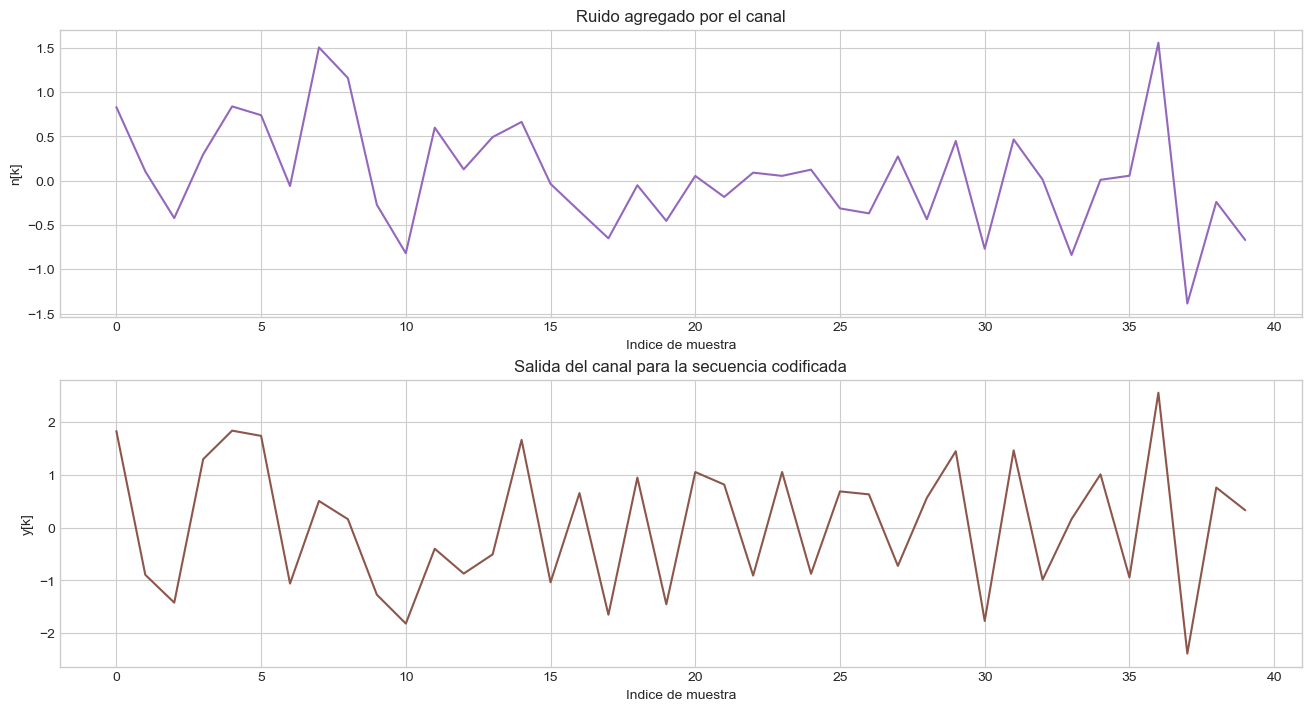

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), constrained_layout=True)

axes[0].plot(noise[:40], color="C4")
axes[0].set_title("Ruido agregado por el canal")
axes[0].set_xlabel("Indice de muestra")
axes[0].set_ylabel("n[k]")

axes[1].plot(channel_output[:40], color="C5")
axes[1].set_title("Salida del canal para la secuencia codificada")
axes[1].set_xlabel("Indice de muestra")
axes[1].set_ylabel("y[k]")

plt.show()


### Histograma de la salida del canal

Al sumar ruido gaussiano a la salida del encoder, la variable deja de valer exactamente `-1` o `+1`. En cambio, se obtiene una variable continua con dos agrupamientos principales: uno alrededor de `-1` y otro alrededor de `+1`. El histograma permite verificar visualmente ese comportamiento.


Primeros 10 simbolos codificados: [ 1 -1 -1  1  1  1 -1 -1 -1 -1]
Primeras 10 muestras de ruido: [ 0.832  0.106 -0.422  0.299  0.84   0.74  -0.06   1.506  1.161 -0.271]
Primeras 10 muestras de salida: [ 1.832 -0.894 -1.422  1.299  1.84   1.74  -1.06   0.506  0.161 -1.271]


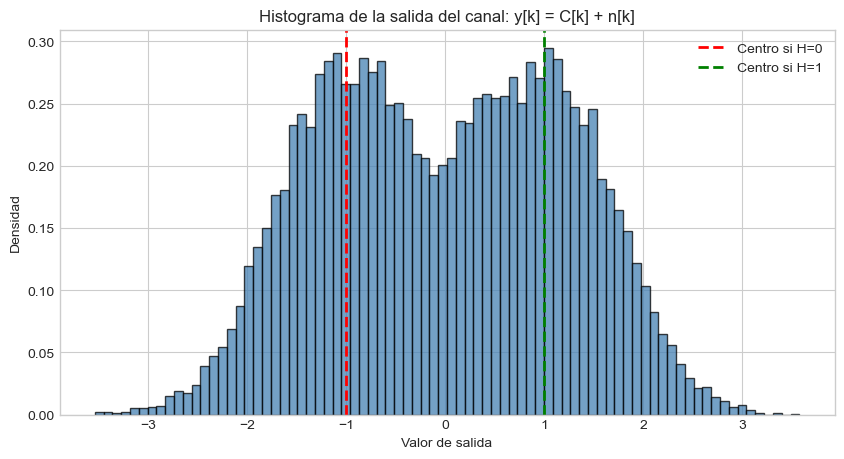

In [6]:
print("Primeros 10 simbolos codificados:", channel_input[:10].astype(int))
print("Primeras 10 muestras de ruido:", np.round(noise[:10], 3))
print("Primeras 10 muestras de salida:", np.round(channel_output[:10], 3))

plt.figure(figsize=(10, 5))
plt.hist(channel_output, bins=80, density=True, alpha=0.75, color="steelblue", edgecolor="black")
plt.axvline(-1, color="red", linestyle="--", linewidth=2, label="Centro si H=0")
plt.axvline(1, color="green", linestyle="--", linewidth=2, label="Centro si H=1")
plt.title("Histograma de la salida del canal: y[k] = C[k] + n[k]")
plt.xlabel("Valor de salida")
plt.ylabel("Densidad")
plt.legend()
plt.show()


Primeros 10 simbolos codificados: [ 1 -1 -1  1  1  1 -1 -1 -1 -1]
Longitud de psi: 16
Longitud del tren de pulsos: 320000
Primeras 48 muestras del tren de pulsos: [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


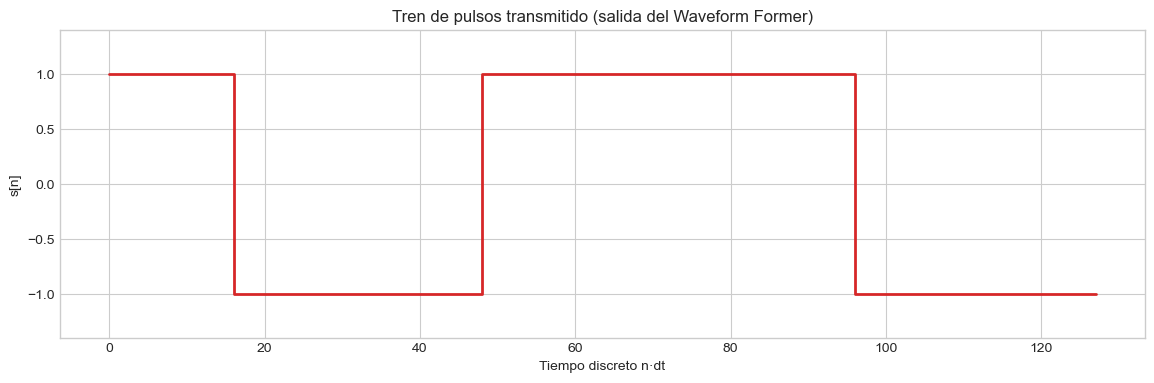

In [7]:
## 4. Waveform Former con unica funcion base psi_1(t)

### Teoria
# La salida del encoder es una secuencia de simbolos antipodales c_i en {-1,+1}.
# El bloque Waveform Former convierte cada simbolo en una forma de onda temporal
# usando la unica funcion base del enunciado:
#
#     psi_1(t) = 1   para t en [0,T]
#
# En tiempo discreto, como T = 16*dt, representamos esa funcion base con un
# pulso rectangular de 16 muestras. Entonces:
#
# - si c_i = +1, se transmite un pulso rectangular positivo
# - si c_i = -1, se transmite un pulso rectangular negativo
#
# La senal transmitida completa se obtiene concatenando un pulso por cada simbolo.

Ns = 16                 # cantidad de muestras por simbolo
dt = 1.0                # periodo de muestreo
T = Ns * dt

psi = np.ones(Ns)

def waveform_former(symbols, psi):
    return np.concatenate([c * psi for c in symbols])

tx_waveform = waveform_former(coded_symbols, psi)

print("Primeros 10 simbolos codificados:", coded_symbols[:10].astype(int))
print("Longitud de psi:", len(psi))
print("Longitud del tren de pulsos:", len(tx_waveform))
print("Primeras 48 muestras del tren de pulsos:", tx_waveform[:48].astype(int))

t_preview = np.arange(preview_bits * Ns) * dt

plt.figure(figsize=(14, 4))
plt.step(t_preview, tx_waveform[:preview_bits * Ns], where="post", linewidth=2, color="C3")
plt.title("Tren de pulsos transmitido (salida del Waveform Former)")
plt.xlabel("Tiempo discreto n·dt")
plt.ylabel("s[n]")
plt.ylim(-1.4, 1.4)
plt.grid(True)
plt.show()

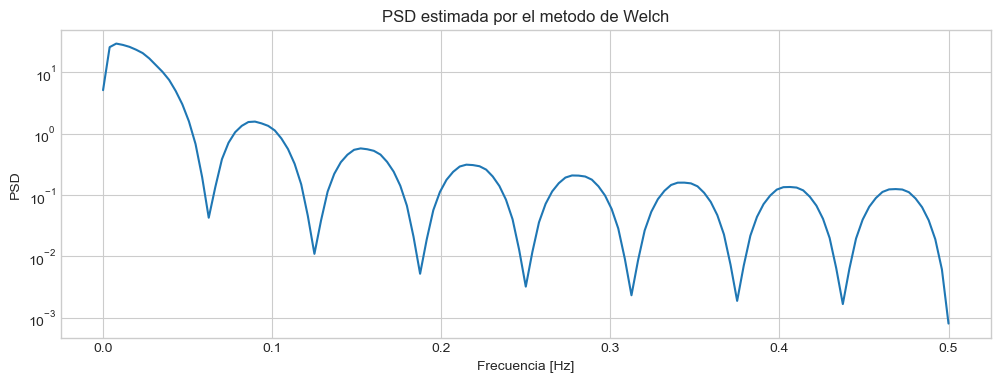

In [8]:
## 5. Densidad espectral de potencia estimada con Welch

from scipy.signal import welch

fs = 1 / dt

f, Pxx = welch(
    tx_waveform,
    fs=fs,
    window="hann",
    nperseg=min(256, len(tx_waveform)),
    noverlap=min(128, len(tx_waveform) // 2),
    scaling="density"
)

plt.figure(figsize=(12, 4))
plt.semilogy(f, Pxx, color="C0")
plt.title("PSD estimada por el metodo de Welch")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.grid(True)
plt.show()

Sí: para el n-Tuple Former tipo matched filter, lo que hay que hacer es convolucionar la señal recibida con la respuesta impulsional del filtro adaptado.

La corrección importante es esta:

formalmente se usa la señal recibida r[n]
si están probando canal ideal, entonces r[n] = s[n], así que en ese caso da lo mismo usar la enviada
Con tu función base rectangular, el filtro adaptado es:

h[n] = psi[::-1]
porque psi es real, entonces el conjugado no cambia nada.

La idea completa sería:

armar tx_waveform
pasarla por el canal
hacer la convolución r[n] * h[n]
graficar la salida del filtro
muestrear en los instantes de decisión para obtener el n-tuple
Podés agregar algo así en la notebook.

Longitud de la senal recibida: 320000
Longitud del filtro adaptado: 16
Longitud de la salida convolucionada: 320015


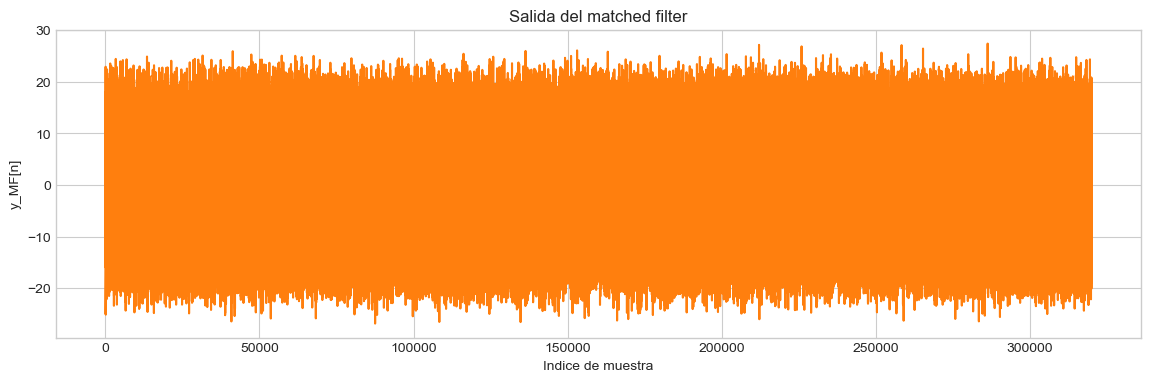

In [9]:
## 6. n-Tuple Former tipo matched filter

# Importante:
# En recepcion se filtra la senal recibida r[n].
# Si el canal es ideal, entonces r[n] = s[n].
# Como antes el canal se aplico sobre coded_symbols, aca volvemos
# a aplicarlo sobre tx_waveform para trabajar con la senal temporal.

rx_waveform, noise_waveform = awgn_channel(tx_waveform, noise_variance, rng, ideal=ideal_channel)

# Filtro adaptado a psi[n]
h_mf = psi[::-1]

# Convolucion
mf_output = np.convolve(rx_waveform, h_mf, mode="full") * dt

print("Longitud de la senal recibida:", len(rx_waveform))
print("Longitud del filtro adaptado:", len(h_mf))
print("Longitud de la salida convolucionada:", len(mf_output))

plt.figure(figsize=(14, 4))
plt.plot(mf_output, color="C1")
plt.title("Salida del matched filter")
plt.xlabel("Indice de muestra")
plt.ylabel("y_MF[n]")
plt.grid(True)
plt.show()

Primeras 10 muestras del n-tuple: [ 17.992 -15.85  -10.19   15.879  21.657  10.381 -13.241 -15.293 -24.723
 -17.978]


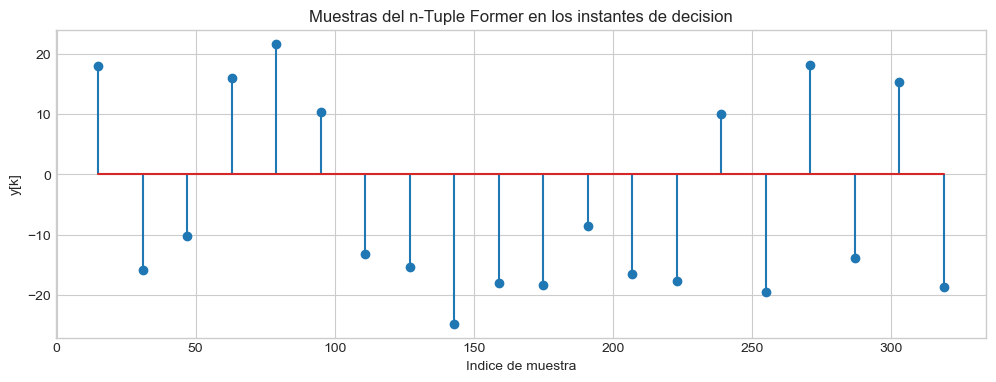

In [10]:
## 7. Muestras del n-Tuple Former

# Se toma una muestra al final de cada intervalo simbolo.
# La cantidad de simbolos se obtiene a partir del tren de pulsos.

num_symbols = len(tx_waveform) // Ns
sample_idx = np.arange(num_symbols) * Ns + (Ns - 1)
y_mf_samples = mf_output[sample_idx]

print("Primeras 10 muestras del n-tuple:", np.round(y_mf_samples[:10], 3))

plt.figure(figsize=(12, 4))
plt.stem(sample_idx[:20], y_mf_samples[:20])
plt.title("Muestras del n-Tuple Former en los instantes de decision")
plt.xlabel("Indice de muestra")
plt.ylabel("y[k]")
plt.grid(True)
plt.show()

Primeras 10 salidas del correlador: [ 17.992 -15.85  -10.19   15.879  21.657  10.381 -13.241 -15.293 -24.723
 -17.978]
Primeras 10 muestras del matched filter: [ 17.992 -15.85  -10.19   15.879  21.657  10.381 -13.241 -15.293 -24.723
 -17.978]
Diferencia maxima: 1.0658141036401503e-14


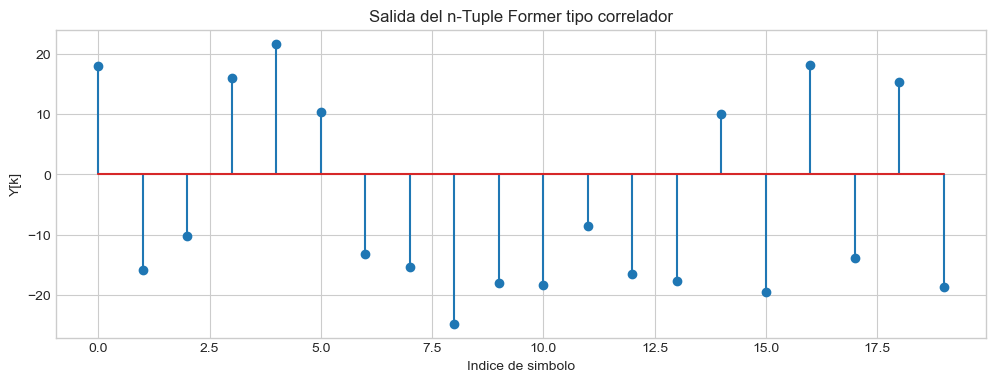

In [11]:
## 8. n-Tuple Former tipo correlador

# El correlador calcula un producto interno por cada simbolo recibido:
#
#   Y[k] = sum r_k[n] * psi[n] * dt
#
# donde r_k[n] es el bloque de Ns muestras correspondiente al simbolo k.
# Con sincronismo perfecto, esta salida debe coincidir con las muestras
# tomadas a la salida del matched filter.

rx_blocks = rx_waveform[:num_symbols * Ns].reshape(num_symbols, Ns)
y_corr = np.sum(rx_blocks * psi, axis=1) * dt

print("Primeras 10 salidas del correlador:", np.round(y_corr[:10], 3))
print("Primeras 10 muestras del matched filter:", np.round(y_mf_samples[:10], 3))
print("Diferencia maxima:", np.max(np.abs(y_corr - y_mf_samples)))

plt.figure(figsize=(12, 4))
plt.stem(np.arange(20), y_corr[:20])
plt.title("Salida del n-Tuple Former tipo correlador")
plt.xlabel("Indice de simbolo")
plt.ylabel("Y[k]")
plt.grid(True)
plt.show()

In [12]:
## 9. Decoder con criterio ML

# Para senalizacion antipodal en AWGN, el criterio ML se reduce
# a comparar la salida del receptor con un umbral en cero:
#
# - si y[k] >= 0, se decide H = 1
# - si y[k] < 0,  se decide H = 0

def ml_decoder(y_samples):
    return (y_samples >= 0).astype(int)

detected_bits = ml_decoder(y_mf_samples)

print("Primeros 20 bits transmitidos: ", bits[:20])
print("Primeros 20 bits detectados:   ", detected_bits[:20])

Primeros 20 bits transmitidos:  [1 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0]
Primeros 20 bits detectados:    [1 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0]


In [13]:
## 10. Probabilidad de error obtenida

num_errors = np.sum(bits != detected_bits)
error_probability = num_errors / len(bits)

print("Cantidad de errores:", num_errors)
print(f"Probabilidad de error estimada: {error_probability:.6f}")

Cantidad de errores: 0
Probabilidad de error estimada: 0.000000
